In [12]:
import numpy as np
from enum import IntEnum

class Action(IntEnum):
    UP = 0
    RIGHT = 1
    DOWN = 2
    LEFT = 3

class CliffWalkingEnv:
    def __init__(self):
        self.shape = (4, 12)
        self.start = (3, 0)
        self.goal = (3, 11)
        self.state = self.start
        
        self.action_space = [Action.UP, Action.RIGHT, Action.DOWN, Action.LEFT]
        
    def reset(self) -> tuple:
        self.state = self.start
        return self.state
        
    def step(self, action: int) -> tuple:
        r, c = self.state
        
        if action == Action.UP:
            next_r, next_c = r - 1, c
        elif action == Action.RIGHT:
            next_r, next_c = r, c + 1
        elif action == Action.DOWN: 
            next_r, next_c = r + 1, c
        elif action == Action.LEFT:
            next_r, next_c = r, c - 1
        else:
            raise ValueError(f"Acțiune invalidă. Acțiunile valide sunt: {[a.value for a in Action]}")
            
        if next_r < 0 or next_r >= self.shape[0] or next_c < 0 or next_c >= self.shape[1]:
            next_r, next_c = r, c
            
        next_state = (next_r, next_c)
        
        if next_state == self.goal:
            self.state = next_state
            return self.state, 0, True
            
        if next_r == 3 and 1 <= next_c <= 10:
            self.state = self.start
            return self.state, -100, False 
            
        self.state = next_state
        return self.state, -1, False

    def render(self):
        grid = np.full(self.shape, 'o', dtype=str)

        grid[3, 1:11] = 'C'
        grid[3, 11] = 'G'
        grid[3, 0] = 'S'
            
        r, c = self.state
        grid[r, c] = 'X'
        
        print('\n'.join(' '.join(row) for row in grid))
        # print("-" * 23)

env = CliffWalkingEnv()
print("Stare inițială:")
env.reset()
env.render()

print(f"\nFacem un pas în sus ({Action.UP.name}={Action.UP.value}):")
env.step(Action.UP)
env.render()

print(f"\nFacem un pas în dreapta ({Action.RIGHT.name}={Action.RIGHT.value}) și un pas în jos ({Action.DOWN.name}={Action.DOWN.value}) - Cădere în prăpastie:")
env.step(Action.RIGHT)
env.step(Action.DOWN)
env.render()

Stare inițială:
o o o o o o o o o o o o
o o o o o o o o o o o o
o o o o o o o o o o o o
X C C C C C C C C C C G

Facem un pas în sus (UP=0):
o o o o o o o o o o o o
o o o o o o o o o o o o
X o o o o o o o o o o o
S C C C C C C C C C C G

Facem un pas în dreapta (RIGHT=1) și un pas în jos (DOWN=2) - Cădere în prăpastie:
o o o o o o o o o o o o
o o o o o o o o o o o o
o o o o o o o o o o o o
X C C C C C C C C C C G


In [14]:
class BaseAgent:
    def __init__(self, shape: tuple, num_actions: int = 4, alpha: float = 0.1, gamma: float = 1.0, epsilon: float = 0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.epsilon = epsilon
        self.num_actions = num_actions
        self.q_table = np.zeros((*shape, num_actions))
        
    def get_action(self, state: tuple) -> int:
        """
        Returnează acțiunea aleasă folosind strategia epsilon-greedy.
        """
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.num_actions)
        else:
            r, c = state
            q_values = self.q_table[r, c]
            max_q = np.max(q_values)
            actions_with_max_q = np.where(q_values == max_q)[0]
            return int(np.random.choice(actions_with_max_q))
            
    def update(self, state: tuple, action: int, reward: float, next_state: tuple, next_action: int):
        raise NotImplementedError("Implementați logica de update în clasele derivate.")

        
class QLearningAgent(BaseAgent):
    def update(self, state: tuple, action: int, reward: float, next_state: tuple, next_action: int):
        r, c = state
        next_r, next_c = next_state
        
        best_next_q = np.max(self.q_table[next_r, next_c])
        
        td_target = reward + self.gamma * best_next_q
        td_error = td_target - self.q_table[r, c, action]
        
        self.q_table[r, c, action] += self.alpha * td_error


class SARSAAgent(BaseAgent):
    def update(self, state: tuple, action: int, reward: float, next_state: tuple, next_action: int):
        r, c = state
        next_r, next_c = next_state
        
        next_q = self.q_table[next_r, next_c, next_action]
        
        td_target = reward + self.gamma * next_q
        td_error = td_target - self.q_table[r, c, action]
        
        self.q_table[r, c, action] += self.alpha * td_error


def train_agent(env, agent, num_episodes=500):
    rewards_per_episode = []
    
    for _ in range(num_episodes):
        state = env.reset()
        action = agent.get_action(state)
        done = False
        total_reward = 0
        
        while not done:
            next_state, reward, done = env.step(action)
            
            next_action = agent.get_action(next_state)
            
            agent.update(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
            
            total_reward += reward
            
        rewards_per_episode.append(total_reward)
        
    return rewards_per_episode

Antrenăm Q-Learning pentru 500 episoade...
Antrenăm SARSA pentru 500 episoade...
Antrenament finalizat!



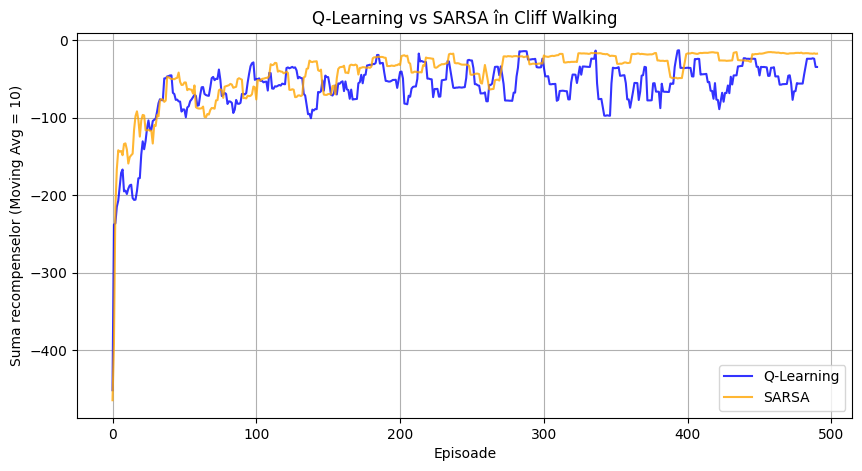

Politica Greedy finală pentru Q-Learning:
↓ | ↓ | ↓ | → | → | ↓ | → | → | → | → | ↓ | ↓
↑ | ↓ | → | → | ↑ | → | → | → | → | ↓ | → | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------
Politica Greedy finală pentru SARSA:
→ | → | → | ↑ | ← | → | → | → | → | → | → | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | ↑ | ↑ | → | ↑ | → | → | ↑ | ↑ | ↑ | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------


In [ ]:
import matplotlib.pyplot as plt

alpha = 0.1
gamma = 1.0
epsilon = 0.1
num_episodes = 500

np.random.seed(42) 
env = CliffWalkingEnv()
q_agent = QLearningAgent(shape=env.shape, alpha=alpha, gamma=gamma, epsilon=epsilon)
sarsa_agent = SARSAAgent(shape=env.shape, alpha=alpha, gamma=gamma, epsilon=epsilon)

print(f"Antrenăm Q-Learning pentru {num_episodes} episoade...")
q_rewards = train_agent(env, q_agent, num_episodes=num_episodes)

print(f"Antrenăm SARSA pentru {num_episodes} episoade...")
sarsa_rewards = train_agent(env, sarsa_agent, num_episodes=num_episodes)

print("Antrenament finalizat!\n")

window = 10
q_smoothed = np.convolve(q_rewards, np.ones(window)/window, mode='valid')
sarsa_smoothed = np.convolve(sarsa_rewards, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(q_smoothed, label='Q-Learning', color='blue', alpha=0.8)
plt.plot(sarsa_smoothed, label='SARSA', color='orange', alpha=0.8)
plt.xlabel('Episoade')
plt.ylabel(f'Suma recompenselor (Moving Avg = {window})')
plt.title('Q-Learning vs SARSA în Cliff Walking')
plt.legend()
plt.grid(True)
plt.show()

def print_greedy_policy(agent, name):
    policy = np.full(env.shape, ' ', dtype=str)
    arrows = {Action.UP: '↑', Action.RIGHT: '→', Action.DOWN: '↓', Action.LEFT: '←'}
    
    for r in range(env.shape[0]):
        for c in range(env.shape[1]):
            if r == 3 and 1 <= c <= 10:
                policy[r, c] = 'C' 
            elif r == 3 and c == 11:
                policy[r, c] = 'G' 
            else:
                best_action = np.argmax(agent.q_table[r, c])
                policy[r, c] = arrows[best_action]
                
    print(f"Politica Greedy finală pentru {name}:")
    for row in policy:
        print(" | ".join(row))
    print("-" * 50)

print_greedy_policy(q_agent, "Q-Learning")
print_greedy_policy(sarsa_agent, "SARSA")

## Răspuns teoretic - Diferențele conceptuale (Cerința a, b, c)

**(a)** În politica *greedy* finală extrasă din matricea Q, **Q-Learning** învață cel mai scurt drum posibil (lipit direct de muchia prăpastiei). Totuși, în timpul antrenamentului efectiv (în care se aplică explorarea epsilon-greedy), **SARSA** obține o sumă cumulată a recompenselor mai mare (scoruri mai puțin negative).

**(b)** Fenomenul provine din diferența fundamentală matematică a calculării **țintei (target-ului)** în regula de update. 
*   **Q-Learning este un algoritm off-policy**. În update-ul său `target = r + gamma * max(Q(s', a'))`, el utilizează maximul posibilităților viitoare. Altfel spus, el aproximează valoarea stării presupunând o conduită viitoare absolut perfectă și ignoră complet faptul că agentul e obligat să exploreze 10% din timp ($\epsilon=0.1$). Astfel, el percepe traversarea pe marginea stâncii ca pe un lucru excelent, ignorând potențialul de a cădea al explorării.
*   **SARSA este un algoritm on-policy**. El folosește în update **acțiune eșantionată**, `target = r + gamma * Q(s', a_viitor)`. Adică, SARSA integrează activ zgomotul aleator în predicția sa. El "simte" prăpastia și realizează că, dacă merge pe margine, 10% din pașii lui se transformă asumat într-un deces (-100). Ca atare, mediul *reward shaping-ului intern* îl constrânge să evalueze rândul imediat deasupra prăpastiei ca fiind foarte neprofitabil, compensând prin devierea traseului cu un rând mai sus (drumul mai lung, dar sigur).

**(c)** Nu există nicio contradicție între cele două realități de la punctul (a) deoarece **scopurile de moment ale algoritmilor diferă fața de parametrii evaluării**. La extragerea matricei greedy manuale ($\epsilon=0$), forțăm zero explorări. În acest "vid" curat de probabilități proaste, modelul teoretic idealizat al lui Q-Learning strălucește, fiind drumul matematic optim (13 pași constant). Totuși, în mediul practic asumat "zgomotos" de la antrenament ($\epsilon=0.1$), tocmai fiindcă SARSA tratează aceste penalizări ca pe realități cu o pondere sigură, abordează problema pragmatic (safe-path) și adună în medie mult mai puține elemente dăunătoare de -100.

In [27]:
class CliffWalkingEnvShaped(CliffWalkingEnv):
    def step(self, action: int) -> tuple:
        r, c = self.state
        
        if action == Action.UP:
            next_r, next_c = r - 1, c
        elif action == Action.RIGHT:
            next_r, next_c = r, c + 1
        elif action == Action.DOWN: 
            next_r, next_c = r + 1, c
        elif action == Action.LEFT:
            next_r, next_c = r, c - 1
            
        if next_r < 0 or next_r >= self.shape[0] or next_c < 0 or next_c >= self.shape[1]:
            next_r, next_c = r, c
            
        next_state = (next_r, next_c)
        if next_state == self.goal:
            self.state = next_state
            return self.state, 0, True
            
        if next_r == 3 and 1 <= next_c <= 10:
            self.state = self.start
            return self.state, -1, False 
            
        self.state = next_state
        return self.state, -5, False


np.random.seed(42)
env_shaped = CliffWalkingEnvShaped()
q_agent_shaped = QLearningAgent(shape=env_shaped.shape, alpha=alpha, gamma=gamma, epsilon=epsilon)
sarsa_agent_shaped = SARSAAgent(shape=env_shaped.shape, alpha=alpha, gamma=gamma, epsilon=epsilon)

train_agent(env_shaped, q_agent_shaped, num_episodes=num_episodes)
train_agent(env_shaped, sarsa_agent_shaped, num_episodes=num_episodes)

print_greedy_policy(q_agent_shaped, "Q-Learning (Shaped Environment)")
print_greedy_policy(sarsa_agent_shaped, "SARSA (Shaped Environment)")

Politica Greedy finală pentru Q-Learning (Shaped Environment):
→ | → | ↓ | ↓ | ↓ | → | → | → | ↓ | → | → | ↓
↑ | → | → | ↑ | → | → | → | ↓ | ↑ | ↓ | ↓ | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------
Politica Greedy finală pentru SARSA (Shaped Environment):
→ | → | ↑ | → | ↓ | → | → | → | ← | → | ← | ↓
→ | → | → | → | ↓ | ↑ | → | → | → | → | → | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------


## Provocare - Epsilon-scheduling

Revenim la prăpastia complet originală (care penalizează masiv, cu $-100$). Aici, în loc să "mințim" agentul că prăpastia nu e periculoasă, îl convingem să se calmeze cu mișcările complet aleatorii din faza de explorare. 

Vom scrie o funcție nouă, `train_agent_decay`, în care la sfârșitul fiecărui episod $\epsilon$-ul stocat în structura agentului scade folosind regula exponențială: $\epsilon_{nou} = \epsilon_{vechi} \cdot \text{decay\_rate}$.  

**Argumentare teoretică (Ce se întâmplă cu ținta SARSA când $\epsilon \rightarrow 0$?):**  
Când nivelul de zgomot $\epsilon$ ajunge efectiv la $0$, agentul SARSA preia acțiunea 100\% *greedy* tot timpul (`argmax`). Ecuația sa de update ia în considerare `next_action`-ul care devine constant acea mutare optimă din tabelul Q. Din acel punct critic asimptotic încolo, SARSA se transformă treptat într-o funcție practic identică cu Q-learning (o exploatare completă a cunoștințelor, încrezătoare și off-policy ca formă), învățând același drum matematic optim pe buza prăpastiei (deoarece rateurile ce îi aduceau acel temut $-100$ dispar în neant și nu mai au loc pentru a fi luate în calcul de $Temporal\ Difference\ Error$).

In [61]:
def train_agent_decay(env, agent, num_episodes=500, decay_rate=0.99, min_epsilon=0.01):
    """
    Antrenează agentul cu descreșterea dinamică a explorării.
    La finalul fiecărui episod, agentul devine din ce în ce mai încrezător în sine.
    """
    rewards_per_episode = []
    
    agent.epsilon = 1.0 
    
    for ep in range(num_episodes):
        state = env.reset()
        action = agent.get_action(state)
        done = False
        total_reward = 0
        
        while not done:
            next_state, reward, done = env.step(action)
            next_action = agent.get_action(next_state)
            
            agent.update(state, action, reward, next_state, next_action)
            
            state = next_state
            action = next_action
            
            total_reward += reward
            
        rewards_per_episode.append(total_reward)
        
        agent.epsilon = max(min_epsilon, agent.epsilon * decay_rate)
        
    return rewards_per_episode


np.random.seed(42)
env_original = CliffWalkingEnv()

q_decay = QLearningAgent(shape=env_original.shape, alpha=alpha, gamma=gamma)
sarsa_decay = SARSAAgent(shape=env_original.shape, alpha=alpha, gamma=gamma)

T_rate = 0.4
q_decay_rewards = train_agent_decay(env_original, q_decay, num_episodes=500, decay_rate=T_rate, min_epsilon=0.0)
sarsa_decay_rewards = train_agent_decay(env_original, sarsa_decay, num_episodes=500, decay_rate=T_rate, min_epsilon=0.0)

print_greedy_policy(q_decay, "Q-Learning (Epsilon-Decay)")
print_greedy_policy(sarsa_decay, "SARSA (Epsilon-Decay)")

Politica Greedy finală pentru Q-Learning (Epsilon-Decay):
← | → | → | → | ↓ | → | → | → | ↓ | ↑ | ← | ↓
↑ | → | → | → | ↑ | → | → | → | → | ↓ | ↓ | ↓
→ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------
Politica Greedy finală pentru SARSA (Epsilon-Decay):
→ | → | → | ↑ | ↓ | → | → | ↓ | → | ↑ | ↓ | ↓
→ | ↑ | → | → | → | ↓ | → | → | → | ↓ | → | ↓
↑ | → | → | → | → | → | → | → | → | → | → | ↓
↑ | C | C | C | C | C | C | C | C | C | C | G
--------------------------------------------------


## Reflecție teoretică (Final)

1. **Ce se întâmplă dacă setați $\epsilon = 0$ de la început pentru Q-learning? Dar pentru SARSA? De ce?**  
Dacă setăm $\epsilon=0$, ambii agenți devin pur **greedy**. Deoarece valorile $Q$ inițiale sunt 0 (sau chiar dacă sunt egale la tie-breaking), agentul nu va face explorare absolut deloc, repetând determinist primele mutări care îi aduc rezultate fără să mai descopere vreodată rute alternative. Practic, nu va învăța soluția global optimă a mediului, blocându-se într-un optim local slab.
  
2. **Dacă $\gamma < 1$ (ex. $\gamma = 0.9$), cum se schimbă preferința fiecărui algoritm pentru drumul scurt vs. drumul sigur? Argumentați.**  
Când $\gamma$ (factorul de discount) scade, agentul devine "miop" – îi pasă cu disperare de recompensele proaste imediate și nu prețuiește recompensarea viitoare a Goal-ului în aceeași măsură. SARSA va fi forțat să devină **și mai fricos/prudent**, fugind și mai repede de -100 penalizare la primii pași, iar Q-learning, bazat pe targetul viitor maxim, s-ar putea să ia rute și mai imprevizibile, deoarece atenuarea exponențială scade diferența marginală dintre drumuri la limită.

3. **Dați un exemplu din lumea reală (nu joc de grilă) în care ați prefera SARSA în locul Q-learning și explicați de ce.**  
Într-un sistem de navigare pentru o **mașină autonomă (self-driving car)**, SARSA este preferat. Q-Learning-ul învață ruta teoretică cea mai scurtă trecând la milimetru de prăpăstii sau pietoni ignorând faptul că manevrele mașinii suferă ocazional o mișcare fizică aleatoare/imperfectă ($\epsilon$). SARSA învață "luând în calcul" erorile de direcție inevitabile ale mecanismului auto, astfel va învăța o rută puțin mai lungă, dar **extrem de sigură** (distantă față de alte obstacole).